### Test 
1. 切换模型为评估模式
2. 模型前向传播
3. 取出预测概率最大的类别
4. 统计预测正确的数量和总数量

In [1]:
import torch 
import torch.utils.data as Data 
from torchvision import transforms
from torchvision.datasets import FashionMNIST
from model import LeNet

In [3]:
def test_data_process():
    test_data = FashionMNIST(root='./data',
                              train=False,
                              transform=transforms.Compose([transforms.Resize(size=28), transforms.ToTensor()]),
                              download=True)
    
    test_dataloader = Data.DataLoader(dataset=test_data,
                                      batch_size = 1,
                                      shuffle = True,
                                      num_workers = 0)
    return test_dataloader
                              

In [4]:
def test_model_process(model,test_dataloader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)
    #初始化参数
    test_corrects = 0.0
    test_num =0

    with torch.no_grad():
        for test_data_x, test_data_y in test_dataloader:
            #将特征放入测试设备
            test_data_x = test_data_x.to(device)
            test_data_y = test_data_y.to(device)
            #设置模式为评估
            model.eval()
            # 前向传播
            output = model(test_data_x )
            # 查找每一行中最大值对应的行
            pre_lab  = torch.argmax(output, dim = 1)
            # 计算正确的数量
            test_corrects += torch.sum(pre_lab == test_data_y.data)
            test_num += test_data_x.size(0)
    
    #计算测试准确率
    test_acc = test_corrects.double().item()/test_num
    print('test_acc: {:.4f}'.format(test_acc))


In [5]:
if __name__ == '__main__':
    #加载模型
    model = LeNet()
    model.load_state_dict(torch.load(r".\best.pth"))
    #加载测试数据
    test_dataloader = test_data_process()
    #测试模型
    test_model_process(model, test_dataloader)

    #设定测试设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    #设置列表值向类别
    class_name = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    with torch.no_grad():
        for b_x,b_y in test_dataloader:
            b_x = b_x.to(device)
            b_y = b_y.to(device)

            model.eval()
            output = model(b_x)
            pre_lab = torch.argmax(output, dim=1)
            result=pre_lab.item()
            label=b_y.item()

            print("预测结果为：",class_name[result],"标签为：",class_name[label])


C:\Users\23017\AppData\Local\Temp\ipykernel_42052\799778614.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r".\best.pth"))


test_acc: 0.8786
预测结果为： Shirt 标签为： Shirt
预测结果为： Ankle boot 标签为： Ankle boot
预测结果为： Sneaker 标签为： Sneaker
预测结果为： Shirt 标签为： T-shirt/top
预测结果为： Sandal 标签为： Sandal
预测结果为： Sneaker 标签为： Sneaker
预测结果为： Pullover 标签为： T-shirt/top
预测结果为： Shirt 标签为： Shirt
预测结果为： Shirt 标签为： Shirt
预测结果为： Trouser 标签为： Trouser
预测结果为： Sandal 标签为： Sandal
预测结果为： Trouser 标签为： Trouser
预测结果为： Shirt 标签为： Pullover
预测结果为： Bag 标签为： Bag
预测结果为： Sandal 标签为： Sandal
预测结果为： Ankle boot 标签为： Ankle boot
预测结果为： Bag 标签为： Bag
预测结果为： Ankle boot 标签为： Ankle boot
预测结果为： Ankle boot 标签为： Ankle boot
预测结果为： Sandal 标签为： Sandal
预测结果为： Ankle boot 标签为： Sneaker
预测结果为： Coat 标签为： Shirt
预测结果为： Bag 标签为： Bag
预测结果为： Ankle boot 标签为： Ankle boot
预测结果为： Pullover 标签为： Pullover
预测结果为： Sandal 标签为： Sandal
预测结果为： Trouser 标签为： Trouser
预测结果为： Shirt 标签为： Coat
预测结果为： Shirt 标签为： Shirt
预测结果为： Ankle boot 标签为： Ankle boot
预测结果为： Trouser 标签为： Trouser
预测结果为： Coat 标签为： Coat
预测结果为： Shirt 标签为： T-shirt/top
预测结果为： Pullover 标签为： Pullover
预测结果为： Trouser 标签为： Trouser
预测结果为： Sneaker 标签为

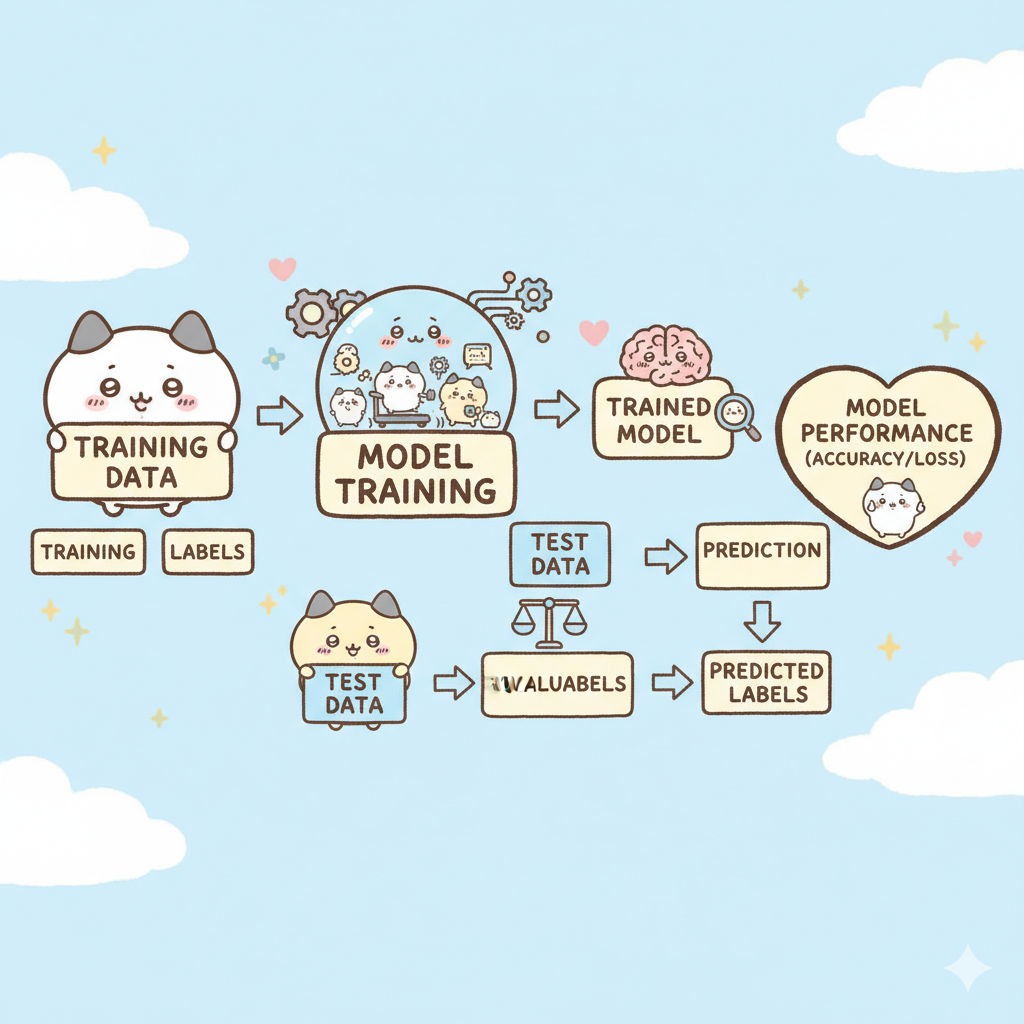